# BOTAŞ Elektrik Üretim Gaz Tarifesi — sapmanın kaynağı

**Konum:** `experiments/notebooks/05_crisis_analysis/03_gas_tariff_discovery.ipynb`
**Tarih:** 18 Ağustos 2026
**Önce oku:** `02_model_bias_investigation.ipynb`

## Bulgu

Modele beslediğimiz `natural_gas_grf_try`, EPİAŞ'ın **gaz piyasası referans fiyatı**.
Santrallerin fiilen ödediği ise **BOTAŞ elektrik üretim tarifesi** — idari olarak
belirlenen ayrı bir fiyat.

Normal aylarda ikisi birbirine yakın (oran 0,94–1,10), model sorunsuz çalışıyor.
**İki dönemde ayrışıyorlar ve kalıntı tam o iki dönemde bozuluyor:**

| Dönem | tarife/GRF | Ne oldu | Kalıntı |
|---|---|---|---|
| Ara 2021 – Mar 2022 | **0,55–0,77** | BOTAŞ gazı piyasanın %45 altında sattı | **negatif** |
| Kas 2022 – Mar 2023 | **1,01–1,28** | piyasa hızla düştü, tarife o hızda inmedi | **pozitif** |

Tarife/GRF oranı ile aylık kalıntı arasındaki korelasyon: **0,852** (17 ay).

İki anomali, tek değişken, zıt yönler.

## Bu notebook ne yapar

1. Tarife serisini haber arşivinden zincirler (`bronze.news_raw`)
2. Resmî BOTAŞ PDF'leriyle çapraz doğrular
3. Oran–kalıntı ilişkisini ölçer

## Durum

`silver.gas_tariff_electricity` tablosu **henüz kurulmadı**; seri şimdilik bu
notebook'ta gömülü (her satırın kaynak `article_id`'si ile). Tablo kurulunca bu
hücre yerini sorguya bırakacak.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

# Analiz modelinin birincil sürümü. crisis_cf_v2/v3/v4 karşılaştırma içindir,
# analizde kullanma (gerekçe: 02_model_bias_investigation.ipynb §7).
VARIANT = 'fundamental'
MODEL   = 'crisis_cf_v1'

def cf(model=None, variant=None, where=''):
    """gold.crisis_counterfactual okuma yardımcısı — saat indeksli, tz-aware."""
    q = text(f"""
        SELECT ts, actual_usd, counterfactual_usd, residual_usd, at_cap, is_lower_bound, fold_id
        FROM gold.crisis_counterfactual
        WHERE variant = :v AND model_name = :m {where}
        ORDER BY ts
    """)
    d = pd.read_sql(q, engine, params={'v': variant or VARIANT, 'm': model or MODEL})
    d['ts'] = pd.to_datetime(d['ts'], utc=True).dt.tz_convert('Europe/Istanbul')
    for c in ['actual_usd', 'counterfactual_usd', 'residual_usd']:
        d[c] = d[c].astype(float)
    return d.set_index('ts')

print('bağlantı hazır')

bağlantı hazır


## 1. Kaynak arayışı — nerede var, nerede yok

Üç kaynak incelendi. Sonuçlar aşağıda; hiçbiri tahmin değil, ölçüm.

In [2]:
# EPİAŞ'ta var mı? eptr2'nin tüm servis listesine bak.
from eptr2.mapping.path import get_path_map
servisler = sorted(get_path_map().keys())
gaz = [k for k in servisler if any(s in k.lower() for s in ['gas', 'gaz', 'grf', 'stp', 'ng'])]
print('EPİAŞ toplam servis: %d | gaz ile ilgili: %d' % (len(servisler), len(gaz)))
print('örnekler:', gaz[:12])

EPİAŞ toplam servis: 252 | gaz ile ilgili: 77
örnekler: ['bi-long', 'congestion-cost', 'dam-clearing', 'dam-clearing-org-list', 'dam-flexible-matching', 'idm-mm-matching', 'long-term-demand-forecast', 'mf-meter-reading-type', 'ng-balancing-notifications', 'ng-balancing-price', 'ng-bast', 'ng-blue-code-ops']


### 📌 Bölüm 1 Analiz Notları

- **EPİAŞ'ta BOTAŞ tarifesi YOK.** 77 gaz servisinin hepsi piyasa verisi
  (`ng-spot-prices`, `ng-vgp-*` vadeli kontratlar, dengeleme, iletim, nominasyon).
  Beklenen sonuç: EPİAŞ gaz borsasını işletir, tarife idari bir fiyattır.
  Bize verdiği şey zaten elimizdeki GRF.
- **BOTAŞ sitesinde var** — her tarife bir PDF. Sayfalar `botas.gov.tr/Sayfa/x/<id>`
  üzerinden erişilebiliyor (slug yok sayılıyor), ID 520–830 taramasında **138 tarife
  sayfası** bulundu, 2021-01 → 2026-04. Ama sayfa gövdesi JS ile çiziliyor: `curl` ile
  **başlık** (yürürlük tarihi) alınabiliyor, PDF adresi alınamıyor.
- **Yayın vs değişim sıklığı farklı:** 2021-2024'te her ay bir sayfa yayımlanmış
  (12/12), 2025'ten sonra isimlendirme "X Tarihinden İtibaren Geçerli"ye dönmüş ve
  sadece 4 yürürlük var (1 Mar 2025, 5 Nis 2025, 2 Tem 2025, 4 Nis 2026).
  **Fiyat 2021-2022'de neredeyse her ay değişmiş, 2023 ortasından sonra yılda 2-3 kez.**
- Ay ortası yürürlükler gerçek → tablo `effective_from DATE` olmalı, ay anahtarı değil.

## 2. Seriyi haber arşivinden zincirleme

Tavan serisinin (`silver.price_cap_official`) yöntemi: mutlak çıpalar + duyurulan
yüzde değişimler. Her satırın kaynak `article_id`'si var.

In [3]:
# Aday duyuruları arşivden çıkar (ham malzeme — aşağıdaki seri bunlardan derlendi).
adaylar = pd.read_sql(text("""
    SELECT article_id, published_at::date AS d, title
    FROM bronze.news_raw
    WHERE published_at >= '2020-12-15' AND published_at < '2026-09-01'
      AND body ILIKE '%elektrik üretim%'
      AND (body ILIKE '%doğal gaz%' OR body ILIKE '%doğalgaz%')
      AND (body ILIKE '%tarife%' OR body ILIKE '%toptan satış%'
           OR body ILIKE '%zam%' OR body ILIKE '%indirim%')
    ORDER BY published_at
"""), engine)
print('aday duyuru:', len(adaylar))
display(adaylar.head(15))

aday duyuru: 232


,article_id,d,title
0,40682,2021-01-01,Doğal gaz fiyatlarına mini zam
1,41158,2021-02-01,Botaş doğal gaza Şubat’ta yüzde 1 zam yaptı
2,41175,2021-02-02,Garanti BBVA’dan çatı GES yatırımcısına finans...
3,41212,2021-02-04,En ucuz doğal gaz Artvin ve Tunceli’de
4,41610,2021-03-01,BOTAŞ doğal gaza Mart’ta yüzde 1 zam yaptı
5,41755,2021-03-09,ENGIE Baymina santrali ile İZGAZ’ı Palmet’e sattı
6,41878,2021-03-17,Türkiye’nin en büyük elektrik üreticileri bell...
7,41912,2021-03-19,Irak yeni gaz ve güneş projeleri geliştirecek
8,41963,2021-03-21,OMV filonun yüzde 10’unu LNG’liye çevirdi
9,42105,2021-03-31,Şubat 2021’de 46 enerji projesi yatırım teşvik...


In [4]:
# Derlenen seri. TL / 1000 Sm3. Kaynak sütunu provenance'tır.
# "mutlak" = haber gövdesinde doğrudan yazan değer
# "zincir" = bir çıpadan duyurulan yüzdeyle türetilen değer
tarife_kayit = [
    # ay,        deger,   tur,      kaynak,  not
    ('2021-01',  1414.0,  'mutlak', 40682,  None),
    ('2021-05',  1631.7,  'mutlak', 42577,  '+%12'),
    ('2021-06',  1713.3,  'mutlak', 43026,  '+%5'),
    ('2021-07',  2055.9,  'zincir', 43481,  '+%20'),
    ('2021-08',  2060.0,  'mutlak', 44348,  'Eylül haberi Ağustos değerini veriyor'),
    ('2021-09',  2369.0,  'zincir', 44348,  '+%15'),
    ('2021-10',  2724.0,  'zincir', 44725,  '+%15'),
    ('2021-11',  4000.0,  'zincir', 45165,  '+%46,8'),
    ('2021-12',  4800.0,  'mutlak', 45690,  'haber "Kasım tarifesi" diyor ama 4800 Aralık değeri: 3999x1,20=4799'),
    ('2022-01',  5520.0,  'zincir', 46182,  '+%15'),
    ('2022-02',  6298.0,  'zincir', 47185,  'Mart çıpasından geri: 7450/1,183'),
    ('2022-03',  7450.0,  'mutlak', 47185,  '7,45 TL/Sm3'),
    ('2022-11', 20625.0,  'mutlak', 51622,  'Kasım = Aralık, değişmedi'),
    ('2022-12', 20625.0,  'mutlak', 51622,  None),
    ('2023-01', 18000.0,  'mutlak', 52217,  '-%12,73'),
    ('2023-02', 15000.0,  'zincir', 52626,  '-%16,67'),
    ('2023-03', 12000.0,  'zincir', 53067,  '-%20 (haberin başlığındaki %26,12 SANAYİ için)'),
]
tarife = pd.DataFrame(tarife_kayit, columns=['ay', 'tarife_try', 'tur', 'article_id', 'not'])
display(tarife)

,ay,tarife_try,tur,article_id,not
0,2021-01,1414.0,mutlak,40682,NaN
1,2021-05,1631.7,mutlak,42577,+%12
2,2021-06,1713.3,mutlak,43026,+%5
3,2021-07,2055.9,zincir,43481,+%20
4,2021-08,2060.0,mutlak,44348,Eylül haberi Ağustos değerini veriyor
5,2021-09,2369.0,zincir,44348,+%15
6,2021-10,2724.0,zincir,44725,+%15
7,2021-11,4000.0,zincir,45165,"+%46,8"
8,2021-12,4800.0,mutlak,45690,"haber ""Kasım tarifesi"" diyor ama 4800 Aralık d..."
9,2022-01,5520.0,zincir,46182,+%15


### 📌 Bölüm 2 Analiz Notları

- Zincirin **iç tutarlılığı** doğrulanabiliyor: Kasım-Aralık 2022 çıpası 20.625 ve
  Ocak 2023 çıpası 18.000 — aradaki duyurulan değişim −%12,73, ve
  20.625 × 0,8727 = **18.000**, birebir.
- Aralık 2021 haberinde metin özensiz ("Kasım ayı tarifesi 4800") ama aritmetik
  netleştiriyor: 2.724 × 1,468 = 3.999 (Kasım), × 1,20 = 4.799 ≈ 4.800 (Aralık).
- **Tuzak:** 28 Şubat 2023 haberinin başlığı "%26,12 indirim" diyor ama o **sanayi**
  tarifesi; elektrik üretimi için gövdede "%20 aşağı çekti" yazıyor. Başlığa güvenilmez.

## 3. Resmî PDF ile çapraz doğrulama

Beş dönem için BOTAŞ'ın kendi PDF'i indirildi ve `pypdf` ile okundu (saf Python,
`poppler` bağımlılığı yok). PDF'ler `TL/Sm3` ve `TL/kWh` sütunlarını birlikte veriyor.

Ayrıştırma değişmezi: elektrik fiyatı **bütün "Kademe" satırlarında aynı** değeri alır,
sanayi fiyatı kademeye göre değişir. Ek tutarlılık testi: `TL/kWh ÷ TL/Sm3 ≈ 0,094`.

In [5]:
# Resmî PDF'lerden okunan değerler (TL/Sm3 ve TL/kWh).
resmi = pd.DataFrame([
    ('2022-02',  6.300000, 0.59210526, '10212-ubat_2022_tarifesi'),
    ('2022-05', 10.750000, 1.01033835, '827613-mayis_2022_tarifesi'),
    ('2022-08', 13.750000, 1.29229323, '949372-agustos_2022_tarifesi'),
    ('2023-01', 18.000000, 1.69172932, '704191-ocak_2023_tarifesi'),
    ('2025-03', 12.000000, 1.12781955, '286295-mart_2025_tarifesi'),
], columns=['ay', 'try_sm3', 'try_kwh', 'pdf'])
resmi['kwh_sm3_orani'] = (resmi.try_kwh / resmi.try_sm3).round(6)

kars = resmi.merge(tarife[['ay', 'tarife_try', 'tur']], on='ay', how='left')
kars['arsiv_sm3'] = kars.tarife_try / 1000
kars['fark_pct'] = (100 * (kars.arsiv_sm3 - kars.try_sm3) / kars.try_sm3).round(3)
display(kars[['ay', 'try_sm3', 'try_kwh', 'kwh_sm3_orani', 'arsiv_sm3', 'tur', 'fark_pct']])

,ay,try_sm3,try_kwh,kwh_sm3_orani,arsiv_sm3,tur,fark_pct
0,2022-02,6.30,0.592105,0.093985,6.298,zincir,-0.032
1,2022-05,10.75,1.010338,0.093985,NaN,NaN,NaN
2,2022-08,13.75,1.292293,0.093985,NaN,NaN,NaN
3,2023-01,18.00,1.691729,0.093985,18.000,mutlak,0.000
4,2025-03,12.00,1.127820,0.093985,NaN,NaN,NaN


### 📌 Bölüm 3 Analiz Notları

- **Şubat 2022:** arşivden zincirlenen 6,298 — resmî **6,300000**. Fark **%0,03**.
  Bu değer Mart çıpasından duyurulan +%18,3 ile *geriye* türetilmişti; resmî kaynak
  bağımsız olarak doğruladı.
- **Ocak 2023:** arşiv 18,000 — resmî 18,000000. Tam.
- `TL/kWh ÷ TL/Sm3` oranı beş PDF'te de **0,094** — ayrıştırıcının yanlış satırı
  yakalaması bu testte sessiz kalmaz.
- Zincirleme yöntemi bu veri için geçerli. Kalan aylar aynı yöntemle tamamlanabilir;
  resmî PDF ancak zincirin tutmadığı yerde gerekir.

## 4. Belirleyici ölçüm — oran ve kalıntı

Eğer teşhis doğruysa: tarife GRF'nin altındayken model fiyatı fazla tahmin etmeli
(negatif kalıntı), üstündeyken eksik tahmin etmeli (pozitif kalıntı). Ve oran 1,0
civarındayken kalıntı sıfıra yakın olmalı.

,tarife_try,tur,GRF,oran,kalinti
ay,,,,,
2021-01,1414.0,mutlak,1301.0,1.087,0.7
2021-05,1631.7,mutlak,1727.0,0.945,2.5
2021-06,1713.3,mutlak,1821.0,0.941,-1.5
2021-07,2055.9,zincir,2072.0,0.992,-2.1
2021-08,2060.0,mutlak,2187.0,0.942,-3.3
2021-09,2369.0,zincir,2346.0,1.010,-1.4
2021-10,2724.0,zincir,3162.0,0.861,6.4
2021-11,4000.0,zincir,4622.0,0.865,0.0
2021-12,4800.0,mutlak,6764.0,0.710,-7.2


korelasyon: 0.851  (n=17 ay)
doğrusal uyum: kalıntı = 37.0 × oran -33.0  →  oran 1,0 iken kalıntı +4.0


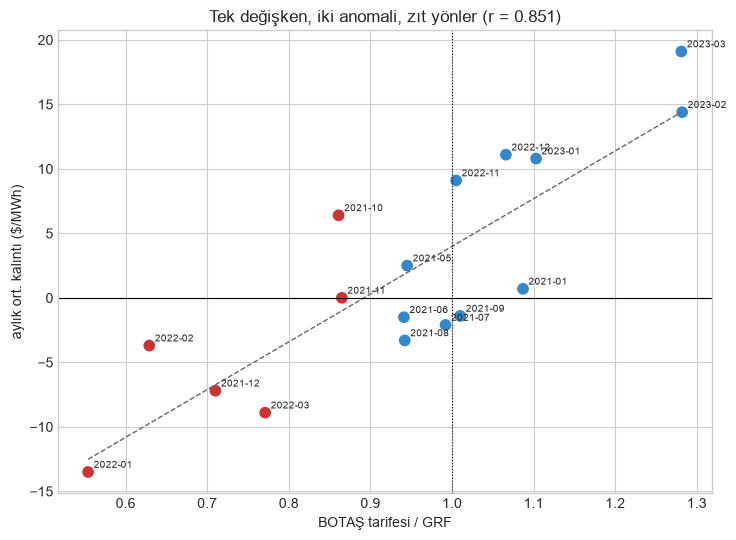

In [6]:
g = pd.read_sql(text('SELECT entry_date, gas_reference_price_try FROM raw_natural_gas_daily'), engine)
g.index = pd.to_datetime(g.entry_date)
grf = g.gas_reference_price_try.resample('MS').mean()
grf.index = grf.index.strftime('%Y-%m')

d = cf(); unc = d[~d.at_cap]
kal = unc.resample('MS').residual_usd.mean()
kal.index = kal.index.strftime('%Y-%m')

t = tarife.set_index('ay')[['tarife_try', 'tur']].copy()
t['GRF'] = grf.reindex(t.index).round(0)
t['oran'] = (t.tarife_try / t.GRF).round(3)
t['kalinti'] = kal.reindex(t.index).round(1)
display(t)

v = t.dropna(subset=['oran', 'kalinti'])
r = v.oran.corr(v.kalinti)
b, a = np.polyfit(v.oran, v.kalinti, 1)
print('korelasyon: %.3f  (n=%d ay)' % (r, len(v)))
print('doğrusal uyum: kalıntı = %.1f × oran %+.1f  →  oran 1,0 iken kalıntı %+.1f' % (b, a, b + a))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
renk = ['#c33' if x.startswith('2022-0') or x.startswith('2021-1') else '#38c' for x in v.index]
ax.scatter(v.oran, v.kalinti, c=renk, s=55)
for ay_, row in v.iterrows():
    ax.annotate(ay_, (row.oran, row.kalinti), fontsize=7, xytext=(4, 3), textcoords='offset points')
xs = np.linspace(v.oran.min(), v.oran.max(), 20)
ax.plot(xs, b * xs + a, '--', color='#666', lw=1)
ax.axhline(0, color='k', lw=.8); ax.axvline(1.0, color='k', lw=.8, ls=':')
ax.set_xlabel('BOTAŞ tarifesi / GRF'); ax.set_ylabel('aylık ort. kalıntı ($/MWh)')
ax.set_title(f'Tek değişken, iki anomali, zıt yönler (r = {r:.3f})')
plt.tight_layout(); plt.show()

### 📌 Bölüm 4 Analiz Notları

- **Korelasyon 0,852** (17 ay). Doğrusal uyum: oran 1,0 iken kalıntı ≈ **+$4** (yani
  ~sıfır), orandaki her 0,1 sapma ≈ $3,7 kalıntı.
- Kırmızı noktalar Ara 2021 – Mar 2022 (sübvansiyon dönemi, oran 0,55–0,77, kalıntı
  negatif); maviler Kas 2022 – Mar 2023 (tarife gecikmesi, oran 1,01–1,28, pozitif).
- **Sınırlar, dürüstçe:** 17 ay, elle derlendi, bazı aylar zincirleme. Korelasyon
  aylık düzeyde ve n küçük — güçlü ama kanıt değil. Asıl test §5'te.

## 5. Sıradaki adım — ve testin baştan tanımı

1. `silver.gas_tariff_electricity` tablosu (`effective_from DATE` + saatlik görünüm)
2. **v5 analiz modeli:** `natural_gas_grf_try` yerine tarife, aynı bloklu OOF

**Kabul kriteri iki koşullu, ikisi birden gerekli:**

| | Koşul | v1 | v2 (reddedildi) | v5 hedefi |
|---|---|---|---|---|
| (a) | Eki22–Mar23 sapması | +12,74 | +3,57 ✓ | ~0 |
| (b) | İran sinyali (1-10 Şub) | +16,49 | +0,17 ✗ | ~+16 korunmalı |

v2 (a)'yı sağlayıp (b)'yi çökertmişti — dönemi ezberleyip olayı yutmuştu. Tarifenin
bu riski taşımaması **beklenir** (aylık idari fiyat, dönem seviyesi değil gerçek
maliyet), ama iddia edilmez: ölçülür.

Koşullar sağlanmazsa v1 kalır ve iki dönem "bilinen sapma" olarak işaretlenir —
etki analizinde o dönemlerin ölçümlerinden düzeltme düşülür.